# AI-Generated Statistical Extension

## Bootstrap Confidence Interval for the Difference in Mean VIQ

This extension uses bootstrap resampling to estimate a 95% confidence interval for the difference in mean VIQ between male and female participants. The result is compared with the independent two-sample t-test from the main analysis.

## 1. Setup

In [1]:
# Import the packages needed for the extension.

import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load and Prepare the Data

The same brain-size dataset used in the main analysis is loaded. VIQ scores are separated by gender, and missing values are removed.

In [2]:
# Load the brain-size dataset.

brain = pd.read_csv(
    "../examples/brain_size.csv",
    sep=";",
    na_values=".",
    index_col=0
)

brain.head()

,Gender,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
1,Female,133,132,124,118.0,64.5,816932
2,Male,140,150,124,NaN,72.5,1001121
3,Male,139,123,150,143.0,73.3,1038437
4,Male,133,129,128,172.0,68.8,965353
5,Female,137,132,134,147.0,65.0,951545


In [3]:
# Separate VIQ scores for male and female participants.

male_viq = brain.loc[
    brain["Gender"] == "Male",
    "VIQ"
].dropna().to_numpy()

female_viq = brain.loc[
    brain["Gender"] == "Female",
    "VIQ"
].dropna().to_numpy()

print("Male sample size:", len(male_viq))
print("Female sample size:", len(female_viq))
print("Male mean VIQ:", male_viq.mean())
print("Female mean VIQ:", female_viq.mean())

Male sample size: 20
Female sample size: 20
Male mean VIQ: 115.25
Female mean VIQ: 109.45


The observed difference is calculated as the male mean VIQ minus the female mean VIQ. A positive value means that the male sample has a higher average VIQ.

In [4]:
# Calculate the observed difference in group means.

observed_difference = male_viq.mean() - female_viq.mean()

print(
    "Observed mean difference "
    "(Male - Female):",
    observed_difference
)

Observed mean difference (Male - Female): 5.799999999999997


## 3. Bootstrap Resampling

Bootstrap resampling repeatedly draws new samples with replacement from the observed data. For each resample, the difference between the male and female mean VIQ scores is calculated.

In [5]:
# Set a random seed so the results are reproducible.

rng = np.random.default_rng(2026)

# Choose the number of bootstrap repetitions.

number_of_bootstraps = 10000

# Create an empty array to store the bootstrap differences.

bootstrap_differences = np.empty(
    number_of_bootstraps
)

# Repeatedly resample each group and calculate the mean difference.

for i in range(number_of_bootstraps):
    male_resample = rng.choice(
        male_viq,
        size=len(male_viq),
        replace=True
    )

    female_resample = rng.choice(
        female_viq,
        size=len(female_viq),
        replace=True
    )

    bootstrap_differences[i] = (
        male_resample.mean()
        - female_resample.mean()
    )

In [6]:
# Calculate the percentile-based 95% bootstrap confidence interval.

lower_limit, upper_limit = np.percentile(
    bootstrap_differences,
    [2.5, 97.5]
)

print("Observed mean difference:", observed_difference)
print("95% bootstrap confidence interval:")
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

Observed mean difference: 5.799999999999997
95% bootstrap confidence interval:
Lower limit: -8.25
Upper limit: 20.451249999999984


## 4. Bootstrap Distribution

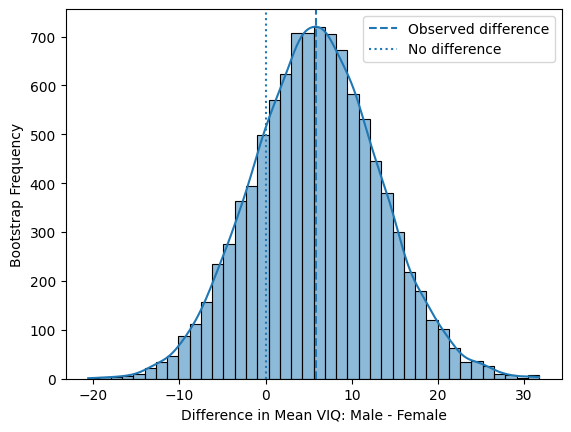

In [7]:
# Plot the distribution of bootstrap mean differences.

sns.histplot(
    bootstrap_differences,
    bins=40,
    kde=True
)

plt.axvline(
    observed_difference,
    linestyle="--",
    label="Observed difference"
)

plt.axvline(
    0,
    linestyle=":",
    label="No difference"
)

plt.xlabel("Difference in Mean VIQ: Male - Female")
plt.ylabel("Bootstrap Frequency")
plt.legend()
plt.show()

The bootstrap distribution is centered near the observed difference of 5.80 points. However, the distribution extends across zero, showing that a difference of zero is still reasonably consistent with the sample data.

## 5. Comparison with the Independent T-Test

In [8]:
# Perform the independent two-sample t-test for comparison.

viq_ttest = sp.stats.ttest_ind(
    male_viq,
    female_viq
)

print("Independent two-sample t-test")
print("Test statistic:", viq_ttest.statistic)
print("P-value:", viq_ttest.pvalue)

Independent two-sample t-test
Test statistic: 0.7726161723275012
P-value: 0.44452876778583217


In [9]:
# Summarize the bootstrap and t-test results.

extension_summary = pd.DataFrame({
    "Observed difference": [observed_difference],
    "Bootstrap CI lower": [lower_limit],
    "Bootstrap CI upper": [upper_limit],
    "T-test statistic": [viq_ttest.statistic],
    "T-test p-value": [viq_ttest.pvalue]
})

extension_summary

,Observed difference,Bootstrap CI lower,Bootstrap CI upper,T-test statistic,T-test p-value
0,5.8,-8.25,20.45125,0.772616,0.444529


The independent t-test has a p-value greater than 0.05, and the 95% bootstrap confidence interval includes zero. Therefore, both methods lead to the same conclusion: the sample does not provide enough evidence of a statistically significant difference in mean VIQ between male and female participants.

## 6. Why This Method Was Appropriate

Bootstrap resampling was a useful extension because it estimates the uncertainty around the observed mean difference without requiring the confidence interval to be calculated only from a theoretical sampling distribution. It also provides a visual distribution of possible mean differences based on the sample.

This method directly addresses the same group-comparison question as the t-test, so it was selected because it was relevant to the dataset rather than simply because it is a commonly used statistical method.

## 7. Conclusion

The male participants had an observed mean VIQ that was 5.80 points higher than the female participants. However, the bootstrap confidence interval included zero, and the independent t-test was not statistically significant. The extension supports the conclusion that the observed difference may be due to sampling variation.